In [1]:
# plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#import plotting_module

# calculations
import xarray as xr
import numpy as np 
import pandas as pd

# regridding
import xesmf as xe

In this notebook: Finding the model TCO up to specified cutoff value (averaged for the 12 calendar months) and then plotting difference plots (Model - observations)

In [2]:
ozone_dataset = xr.open_dataset("/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.002/atm/proc/tseries/month_1/FCnudged_f09.mam.mar27.2000_2021.002.cam.h0.O3.200201-202412.nc")
ps_dataset = xr.open_dataset('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.002/atm/proc/tseries/month_1/FCnudged_f09.mam.mar27.2000_2021.002.cam.h0.PS.200201-202412.nc')

In [3]:
ozone = ozone_dataset["O3"]
p0 = ozone_dataset["P0"]
hyai = ozone_dataset["hyai"]
hybi = ozone_dataset["hybi"]
ps = ps_dataset['PS']
lev = ozone_dataset.coords['lev']
num_lev = lev.shape[0]

In [4]:
# convert to hPa from Pa
p0 = p0.copy() / 100
ps = ps.copy() / 100

In [5]:
start_date = '2005-02-01'
end_date = '2025-01-01'

# group the 240 month dates based on calendar months for both PS and O3 variables

truncated_ozone = ozone.sel(time=slice(start_date, end_date))
ozone_monthly_mean = truncated_ozone.groupby('time.month').mean('time')
ozone_monthly_mean = ozone_monthly_mean.transpose('lev','month','lat','lon')

truncated_ps = ps.sel(time=slice(start_date, end_date))
ps_monthly_mean = truncated_ps.groupby('time.month').mean('time')
ps_monthly_mean = ps_monthly_mean.transpose('month','lat','lon')

Tropospheric column calculations:

Calculating pressure at hybrid levels
p(k) = a(k) * p0 + b(k) * ps

In [6]:
### select threshold value in hPa
threshold = 100

# constants / conversion factor
NAv = 6.0221415e+23                       # molecules in mole
g = 9.81                                  # gravity
MWair = 28.94                             # g/mol
xp_const = (NAv * 10)/(MWair*g)           # scaling factor, pa to hPa and cm to m
DU_CONVERSION = 2.69 * 10**16

In [7]:
# Initialize pressure edge arrays
mod_press_edge_top = xr.zeros_like(ozone_monthly_mean)
mod_press_edge_bottom = xr.zeros_like(ozone_monthly_mean)

In [8]:
# Calculate pressure edge arrays
# Indices start at the top and end at the bottom
for i in range(num_lev):
    mod_press_edge_top[i,:,:,:] = hyai[i]*p0 + hybi[i]*ps_monthly_mean
    mod_press_edge_bottom[i,:,:,:] = hyai[i+1]*p0 + hybi[i+1]*ps_monthly_mean

In [9]:
filtered_300hpa_upper = mod_press_edge_top.where(mod_press_edge_top >= threshold, drop=False)
filtered_300hpa_lower = mod_press_edge_bottom.where(mod_press_edge_bottom >= threshold, drop=False)

In [10]:
filtered_deltap = filtered_300hpa_lower - filtered_300hpa_upper

pres_top_v_300 = mod_press_edge_top - threshold
pres_bottom_v_300 = mod_press_edge_bottom - threshold

In [11]:
filtered_deltap_sliver = pres_bottom_v_300
filtered_deltap_sliver = filtered_deltap_sliver.where(pres_bottom_v_300 >= 0)
filtered_deltap_sliver = filtered_deltap_sliver.where(pres_top_v_300 < 0)

In [12]:
filtered_deltap_sliver = filtered_deltap_sliver.fillna(0)

In [13]:
# sum up both the layer edge and the pressure column to the ground

combined_filtered_deltap = filtered_deltap.copy().fillna(0) + filtered_deltap_sliver

In [14]:
ozone_array = xr.zeros_like(ozone_monthly_mean)
ozone_array = ozone_monthly_mean.where(combined_filtered_deltap > 0)

In [15]:
ozone_array = ozone_array.fillna(0)

In [16]:
ozone_column = xr.dot(combined_filtered_deltap, xp_const*ozone_array, dims='lev')

In [17]:
ozone_full_du_column = ozone_column.copy() / DU_CONVERSION

Regridding and plotting

In [18]:
omi_mls_ds = xr.open_dataarray("/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMIMLS_100hpa_monthly_mean_2005_2024_full.nc")
omi_mls_ds = omi_mls_ds.rename({'latitude': 'lat', 'longitude': 'lon'})

# shifting longitude
omi_mls_ds['lon'] = omi_mls_ds['lon'] % 360
omi_mls_ds = omi_mls_ds.sortby('lon')

In [19]:
regridder = xe.Regridder(ozone_full_du_column, omi_mls_ds, 'bilinear', periodic=True)  
cesm_regridded = regridder(ozone_full_du_column)

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Subtract measurements from model output, then plot

In [20]:
difference = cesm_regridded - omi_mls_ds

num_nan = (difference.isnull().sum() / difference.size).values
print(f"{num_nan:.3f}" + "% NaN values in difference DataArray")

0.117% NaN values in difference DataArray


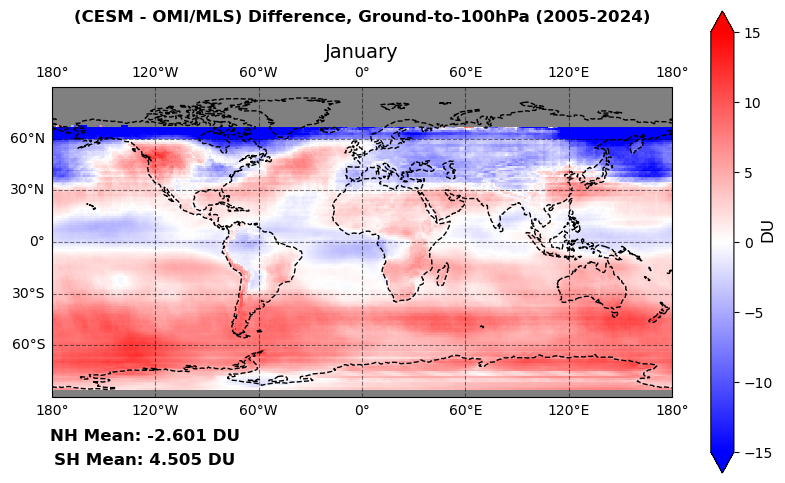

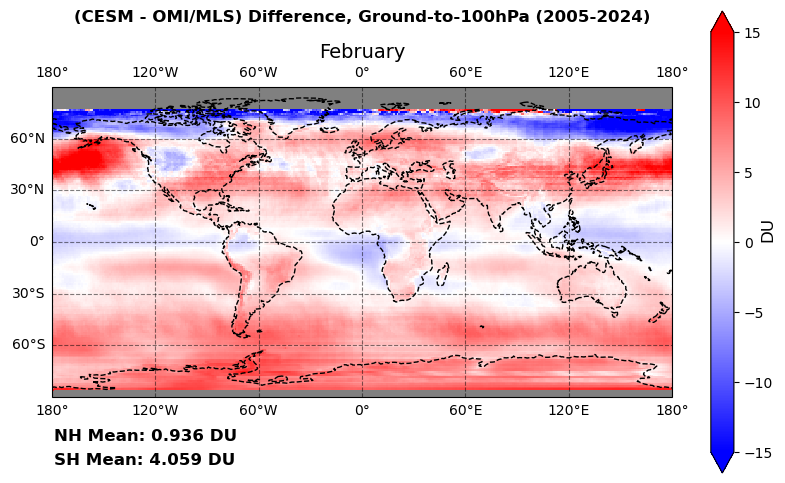

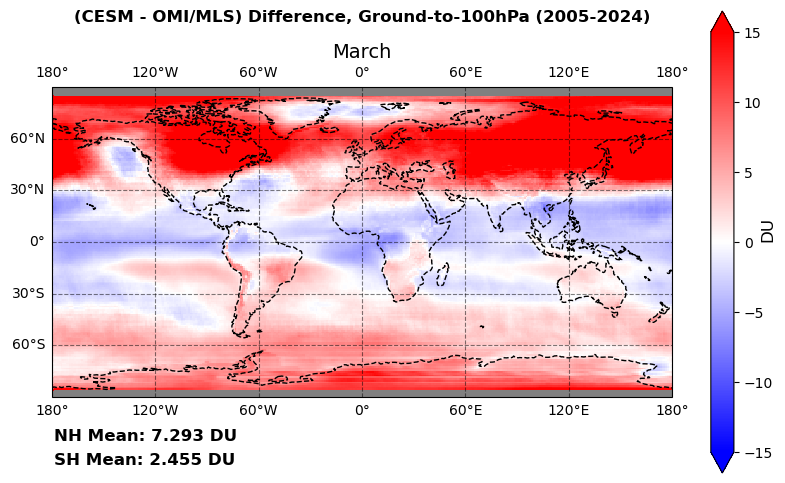

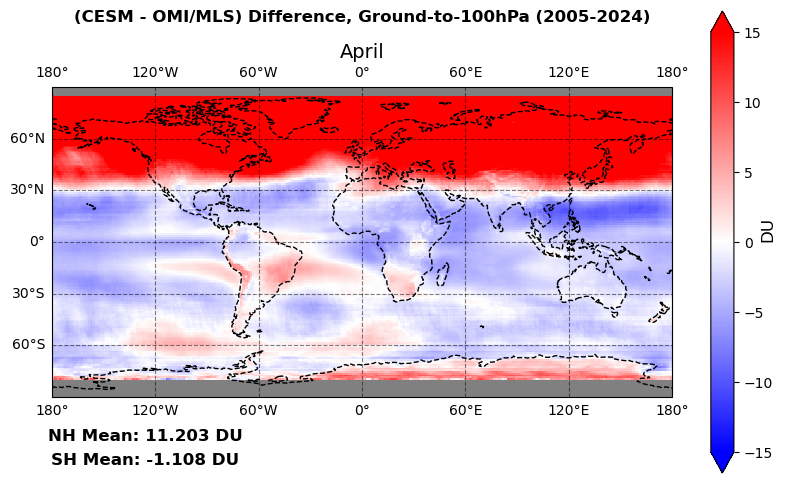

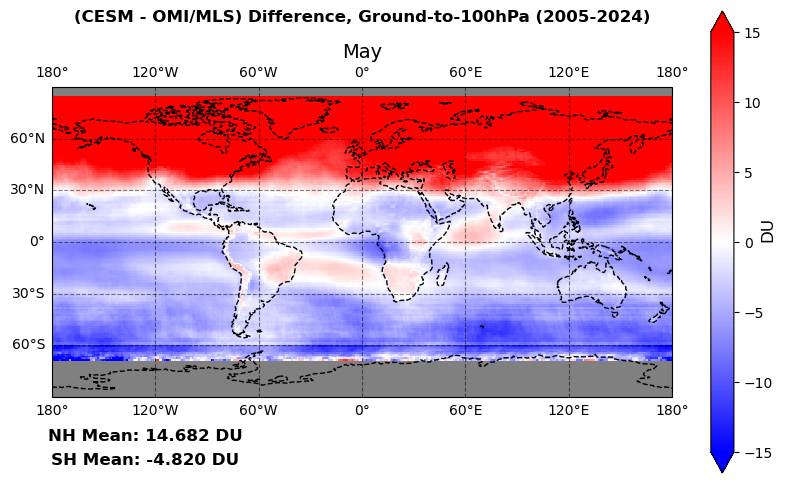

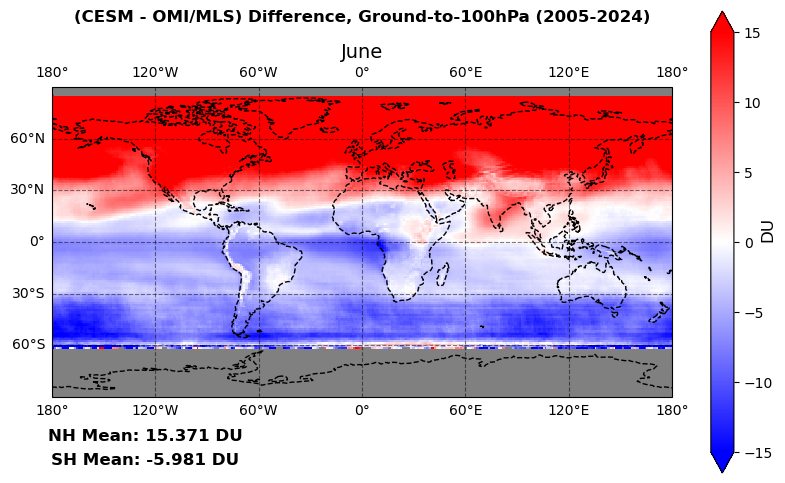

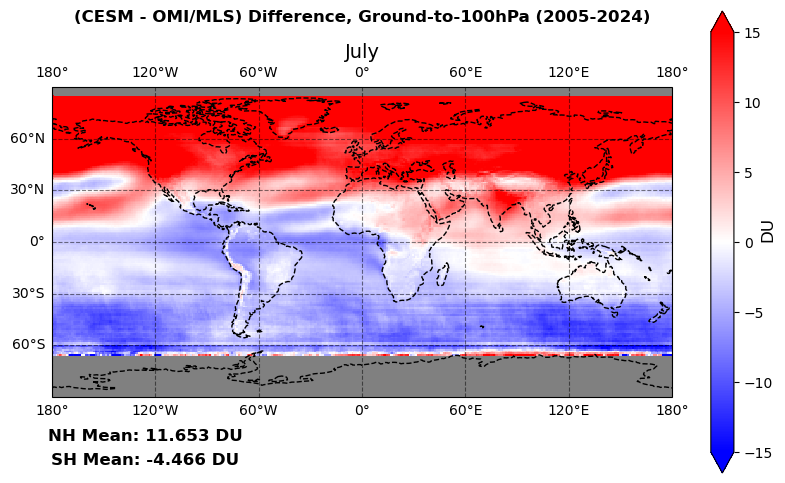

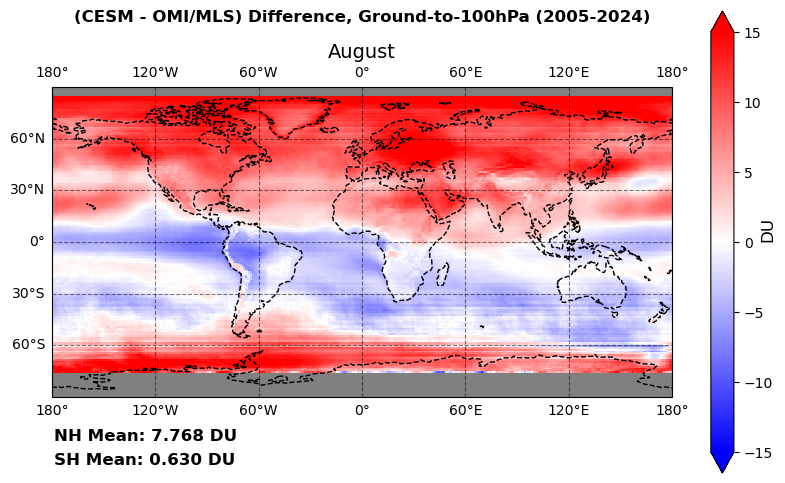

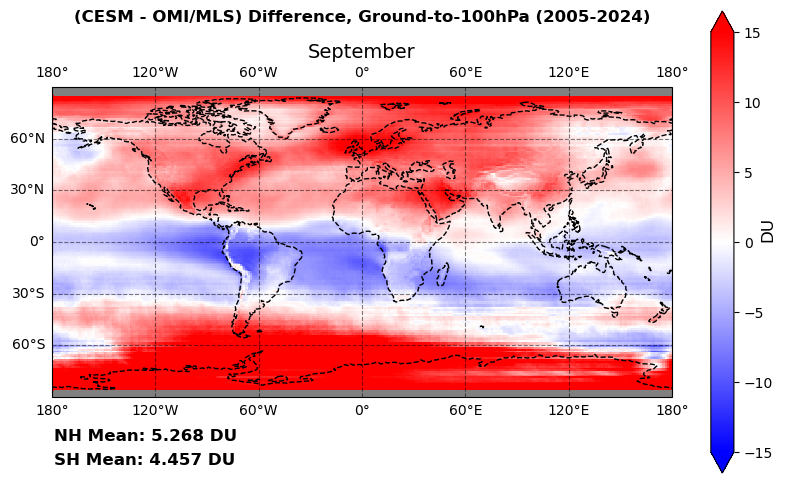

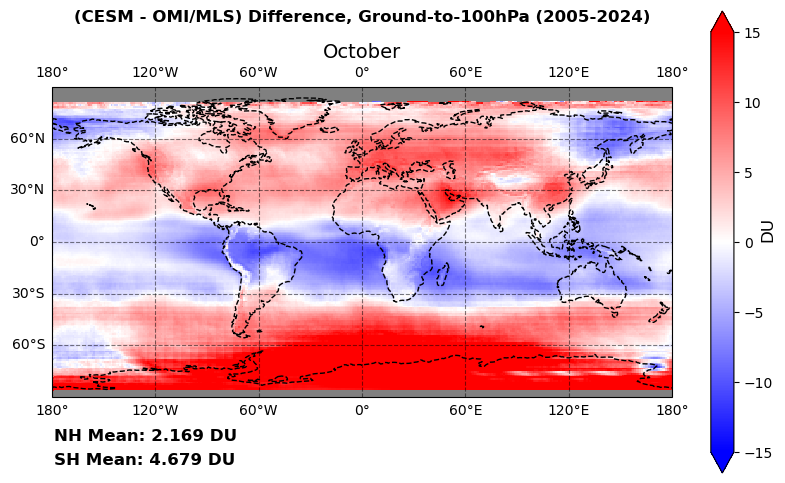

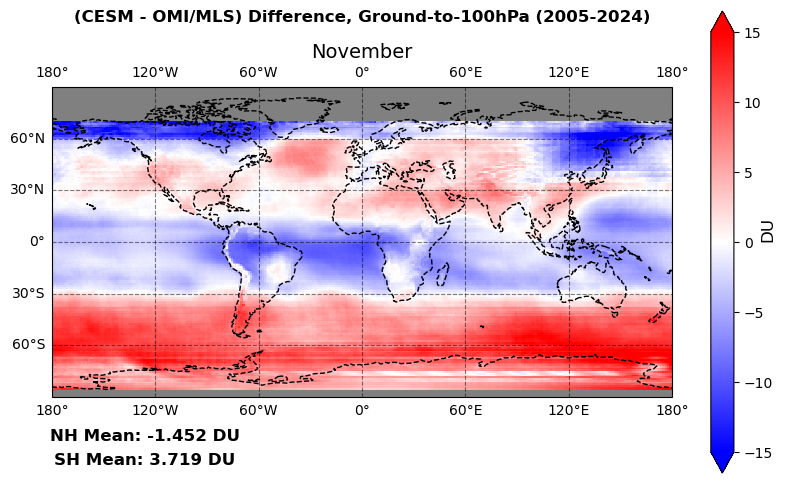

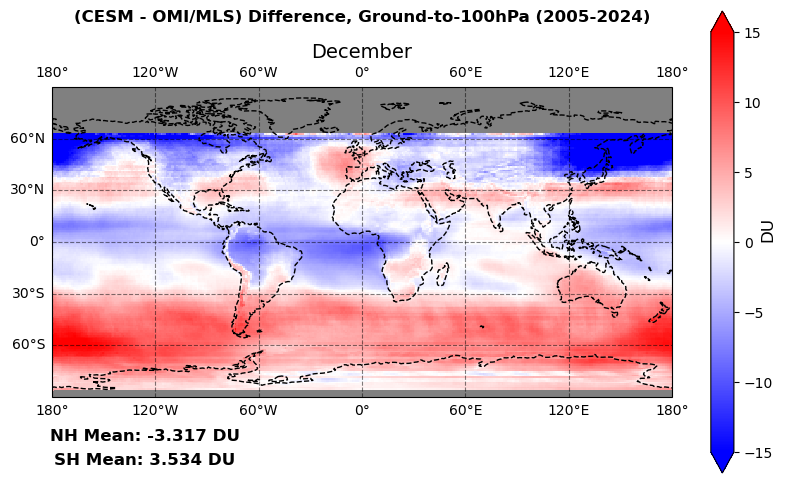

In [24]:
# plot the monthly means

month_list = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l'] # for cycling through figures to create a gif

i=0

for month in month_list:
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_facecolor('gray')
    difference[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), 
                         x='lon', y='lat', vmin=-15, vmax=15, extend='both', cmap='bwr')
    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_global()

    # adding gridlines
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False

    ax.set_title(str(month), fontsize=14)
    formatted_mean = f"{difference[i].mean().data:.3f}"
    
    nh_formatted_mean = f"{difference[i].sel(lat=slice(0,90)).mean(dim={'lat','lon'}, skipna=True).data:.3f}"
    ax.text(0.15, -0.15, 'NH Mean: ' + str(nh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=12, fontweight='bold')
    
    sh_formatted_mean = f"{difference[i].sel(lat=slice(-90,0)).mean(dim={'lat','lon'}, skipna=True).data:.3f}"
    ax.text(0.15, -0.23, 'SH Mean: ' + str(sh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=12, fontweight='bold')

    ax.text(0.5, 1.2, '(CESM - OMI/MLS) Difference, Ground-to-' + str(threshold) + 'hPa (2005-2024)', va='bottom', ha='center',
            transform=ax.transAxes, rotation='horizontal', fontsize=12, fontweight='bold')

    
    ax.text(1.155, 0.5, 'DU', va='bottom', ha='center',
            transform=ax.transAxes, rotation='vertical', fontsize=12)

    #plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/difference_plots/100hpa_diff_pngs/Monthly_Diff-" + str(alphabet[i]))
    plt.show()
    i+=1

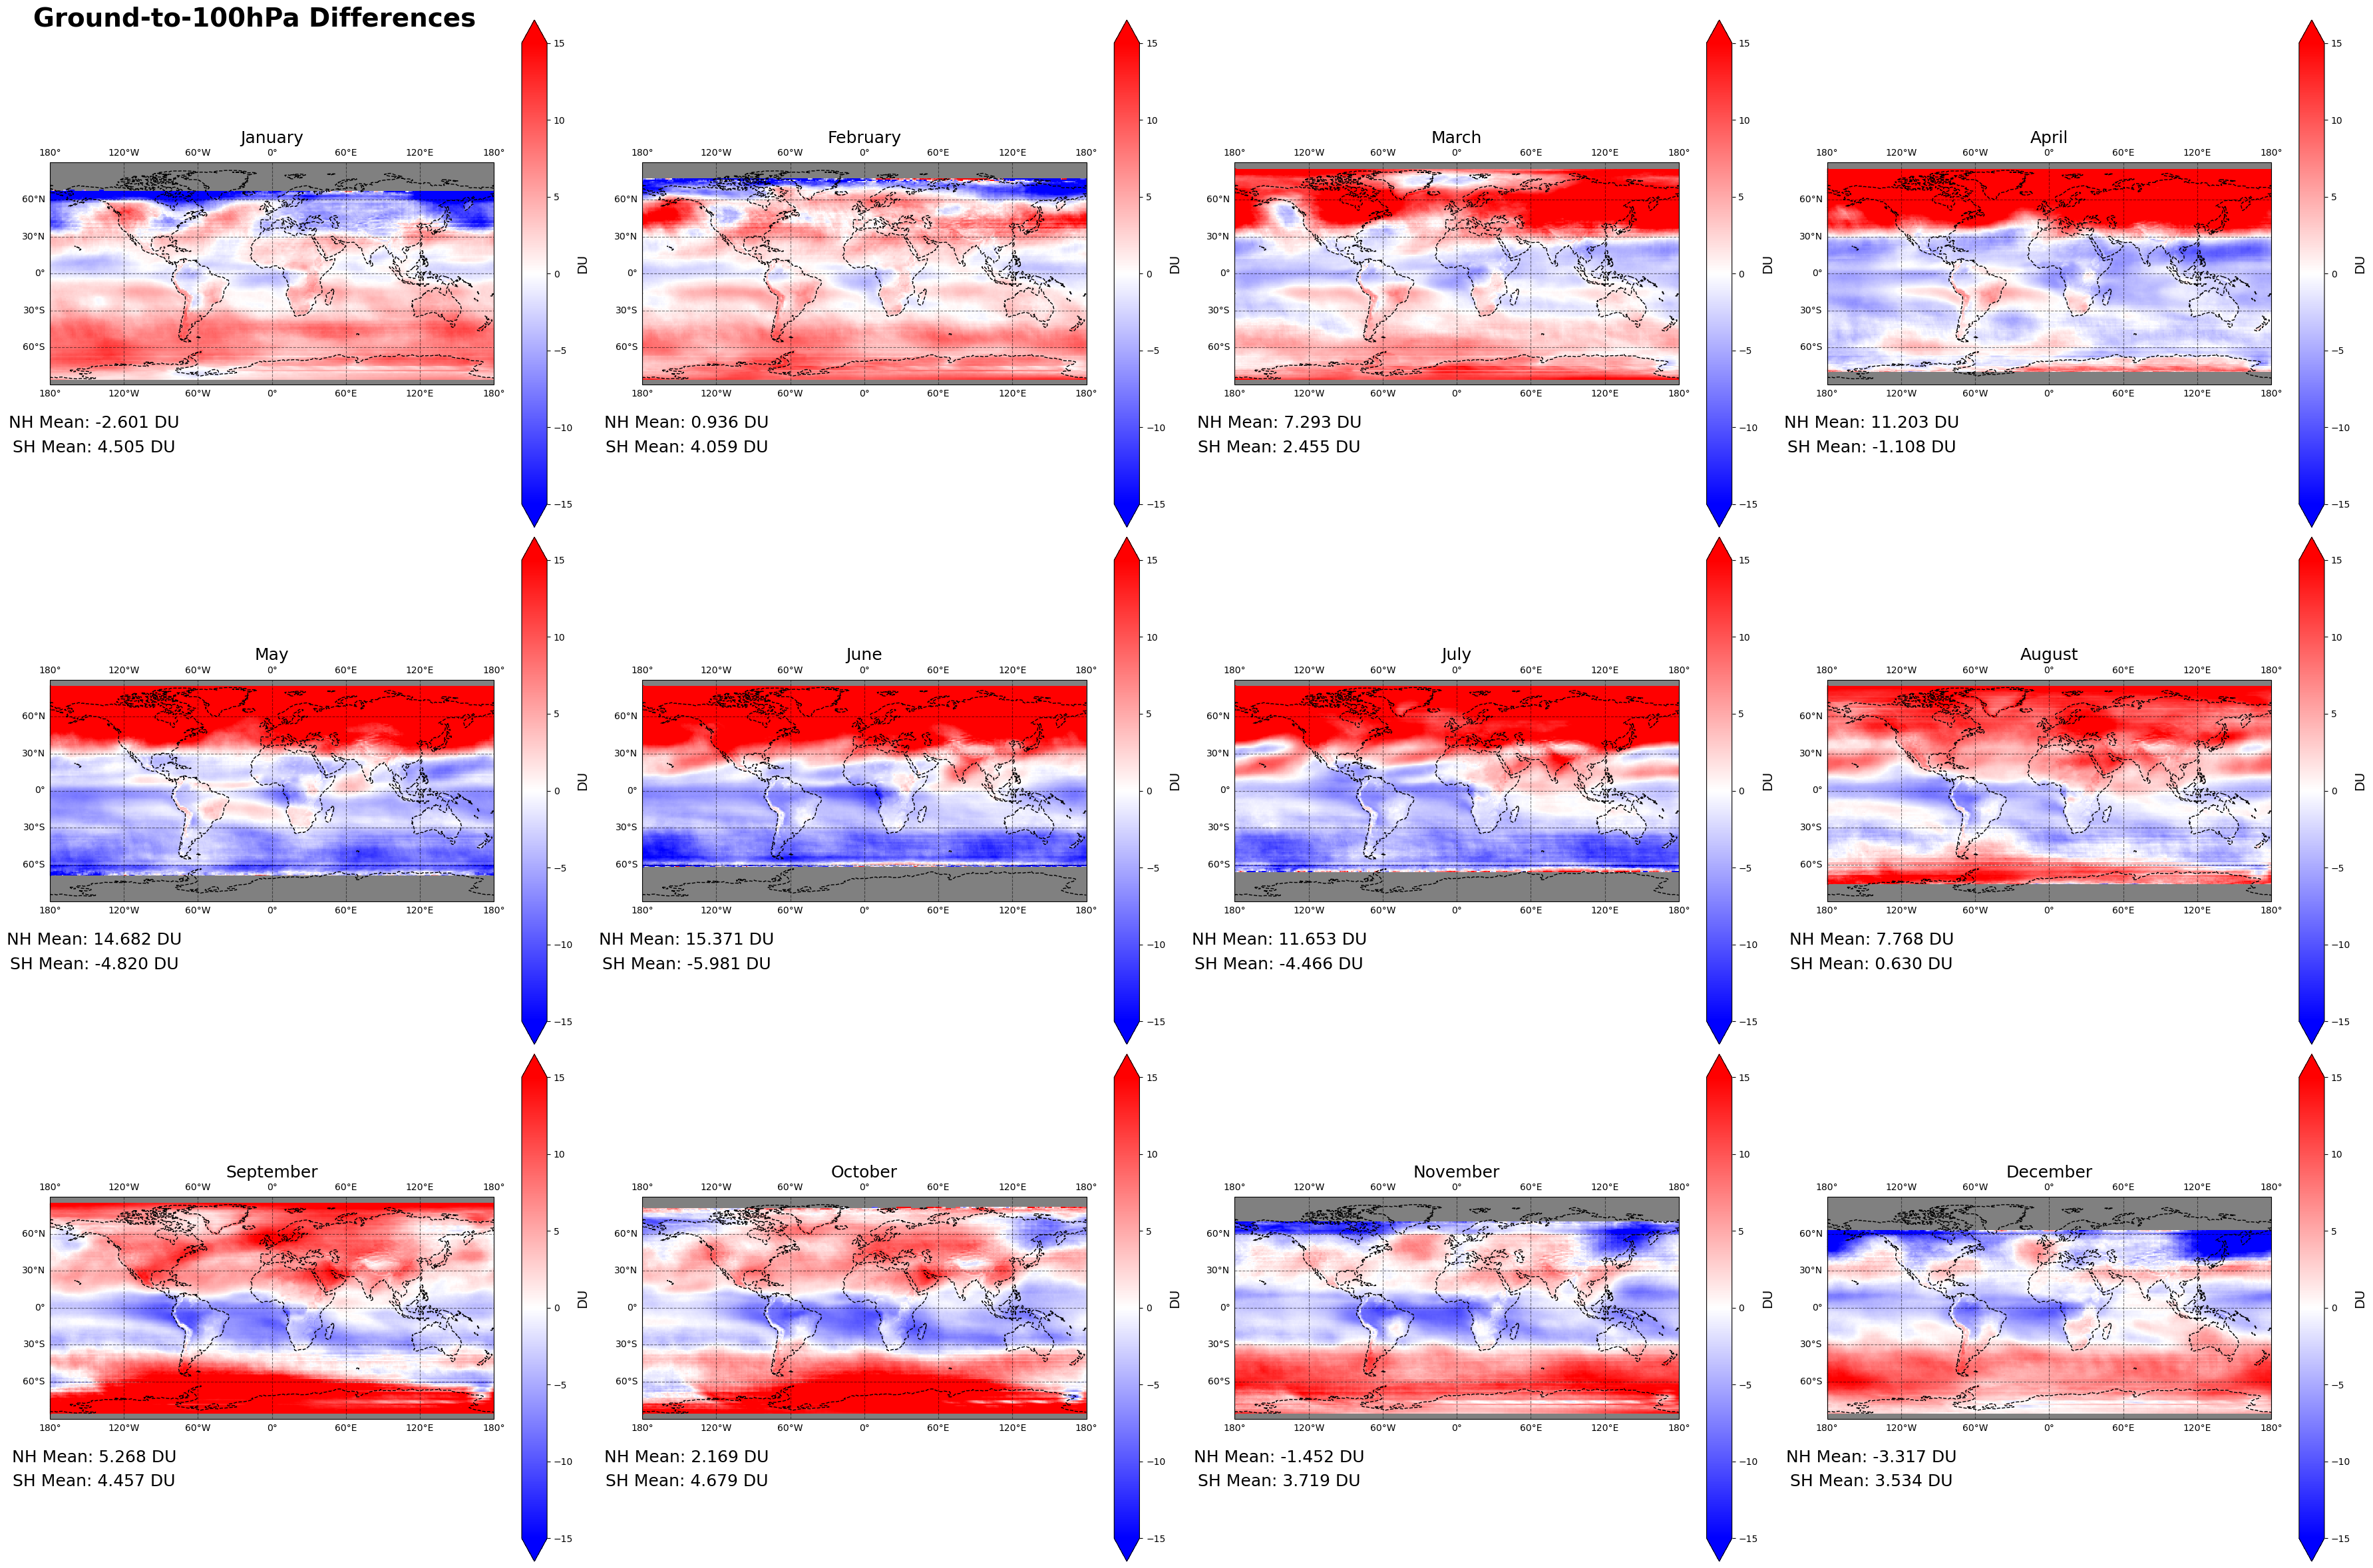

In [22]:
month_list = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(36, 24), subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    difference[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), vmin=-15, vmax=15, extend='both', cmap='bwr')

    ax.set_global()
    ax.set_facecolor('gray')
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False
    
    # adding textual info
    nh_formatted_mean = f"{difference[i].sel(lat=slice(0,90)).mean(dim={'lat','lon'}, skipna=True).data:.3f}"
    ax.text(0.10, -0.21, 'NH Mean: ' + str(nh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=18)
    
    sh_formatted_mean = f"{difference[i].sel(lat=slice(-90,0)).mean(dim={'lat','lon'}, skipna=True).data:.3f}"
    ax.text(0.10, -0.32, 'SH Mean: ' + str(sh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=18)

    # add units to colorbar
    ax.text(1.2, 0.5, 'DU', va='bottom', ha='center',
            transform=ax.transAxes, rotation='vertical', fontsize=14)
    

    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_title(f'{month_list[i]}', fontsize=18)
    plt.suptitle("Ground-to-" + str(threshold) + "hPa Differences", 
                 fontsize=28, ha='right', x=0.2, fontweight='bold')
    plt.tight_layout()


#plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/difference_plots/Difference_Monthly_Climatology_100hPa")
plt.show()